Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,393,094 (28.20 MB)

 Trainable params: 7,393,094 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 51s 955ms/step - accuracy: 0.2933 - loss: 1.9605 - val_accuracy: 0.4198 - val_loss: 1.4309
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 48s 937ms/step - accuracy: 0.4443 - loss: 1.3579 - val_accuracy: 0.4864 - val_loss: 1.3620
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 50s 977ms/step - accuracy: 0.5087 - loss: 1.2311 - val_accuracy: 0.5086 - val_loss: 1.2824
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 49s 962ms/step - accuracy: 0.5786 - loss: 1.0711 - val_accuracy: 0.5160 - val_loss: 1.2757
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 47s 908ms/step - accuracy: 0.6454 - loss: 0.9476 - val_accuracy: 0.5210 - val_loss: 1.3219
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 85s 982ms/step - accuracy: 0.7048 - loss: 0.7813 - val_accuracy: 0.5728 - val_loss: 1.3545
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 80s 937ms/step - accuracy: 0.7351 - loss: 0.7060 - val_accuracy: 0.5704 - val_loss: 1.3542
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 48s 938ms/step - accuracy: 0.8020 - loss: 0.5756 - val_accu

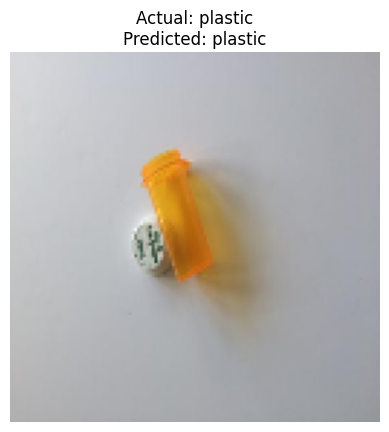

Image 2
Actual    : metal
Predicted : metal
------------------------------


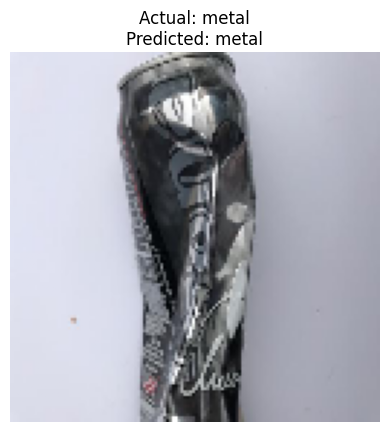

Image 3
Actual    : metal
Predicted : plastic
------------------------------


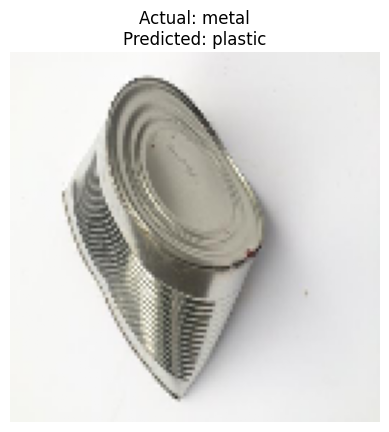

Image 4
Actual    : cardboard
Predicted : cardboard
------------------------------


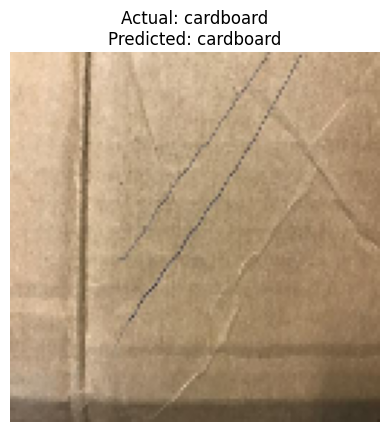

Image 5
Actual    : glass
Predicted : glass
------------------------------


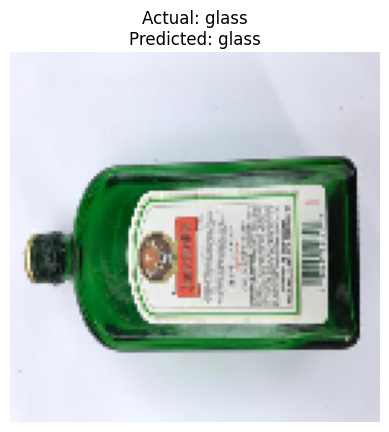

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Input, Dropout

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Dataset Path
dataset_path = "/content/drive/MyDrive/Deep Learning/Garbage classification/Garbage classification"

images = []
labels = []

# Load Images
for class_name in os.listdir(dataset_path):

    class_folder = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_folder):

        for image_name in os.listdir(class_folder):

            image_path = os.path.join(class_folder, image_name)

            try:
                img = load_img(image_path,
                               target_size=(128,128))

                img = img_to_array(img)

                images.append(img)

                labels.append(class_name)

            except:
                pass

# Convert to numpy arrays
X = np.array(images)

# Normalize
X = X / 255.0

# Encode Labels
encoder = LabelEncoder()
y = encoder.fit_transform(labels)

# Class Names
classes = encoder.classes_

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# CNN Model
model = Sequential()

model.add(Input(shape=(128,128,3)))

model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(len(classes),activation='softmax'))

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Train
model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

# Evaluate
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

# Predictions
predictions = model.predict(X_test[:5])

for i in range(5):

    predicted_label = np.argmax(predictions[i])

    actual_label = y_test[i]

    print(f"Image {i+1}")
    print(f"Actual    : {classes[actual_label]}")
    print(f"Predicted : {classes[predicted_label]}")
    print("-"*30)

    plt.imshow(X_test[i])

    plt.title(
        f"Actual: {classes[actual_label]}\n"
        f"Predicted: {classes[predicted_label]}"
    )

    plt.axis('off')
    plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
